In [4]:
import numpy as np
import ot
from ot import sliced_wasserstein_distance
from scipy.stats import wasserstein_distance

rng  = np.random.default_rng(42)
N    = 600
GRID = 4
CELL = 0.6    # half-width of each cell — points live in a small cube
GAP  = 1.4    # empty space between adjacent cells
STEP = 2 * CELL + 2 * GAP   # center-to-center distance between adjacent cells

print(f"Cell side      : {2*CELL:.2f}")
print(f"Min inter-cell : {2*GAP:.2f}   ← guaranteed minimum transport distance")
print(f"Grid extent    : {GRID*STEP:.2f}")

# ── Build cell centers on the spaced-out grid ──────────────────────────────────
even_cells, odd_cells = [], []
for i in range(GRID):
    for j in range(GRID):
        for k in range(GRID):
            center = np.array([(i+0.5)*STEP, (j+0.5)*STEP, (k+0.5)*STEP])
            (even_cells if (i+j+k) % 2 == 0 else odd_cells).append(center)

even_cells = np.array(even_cells)
odd_cells  = np.array(odd_cells)

def sample_cells(cells, n, rng, cell_hw):
    idx = rng.integers(0, len(cells), size=n)
    return cells[idx] + rng.uniform(-cell_hw, cell_hw, size=(n, 3))

cloud_A = sample_cells(even_cells, N, rng, CELL)
cloud_B = sample_cells(odd_cells,  N, rng, CELL)

# ── Diagnostics ───────────────────────────────────────────────────────────────
print(f"\n── Axis-aligned W₁ marginals ──")
for i, name in enumerate(["x", "y", "z"]):
    w1 = wasserstein_distance(cloud_A[:, i], cloud_B[:, i])
    print(f"  W₁ on {name}-axis: {w1:.4f}")

sw = sliced_wasserstein_distance(cloud_A, cloud_B, n_projections=1000, seed=0, p=1)
print(f"\nSliced Wasserstein (p=1): {sw:.4f}")

a = np.ones(N) / N
b = np.ones(N) / N
M = ot.dist(cloud_A, cloud_B, metric='euclidean')
print(f"Cost matrix: min={M.min():.3f}  max={M.max():.3f}")

W = ot.emd2(a, b, M, numItermax=int(1e7))
print(f"Full Wasserstein  (W₁):  {W:.4f}")
print(f"Ratio W / SW: {W/sw:.2f}x")

Cell side      : 1.20
Min inter-cell : 2.80   ← guaranteed minimum transport distance
Grid extent    : 16.00

── Axis-aligned W₁ marginals ──
  W₁ on x-axis: 0.1989
  W₁ on y-axis: 0.4870
  W₁ on z-axis: 0.3356

Sliced Wasserstein (p=1): 0.5364
Cost matrix: min=2.820  max=22.500
Full Wasserstein  (W₁):  3.3039
Ratio W / SW: 6.16x


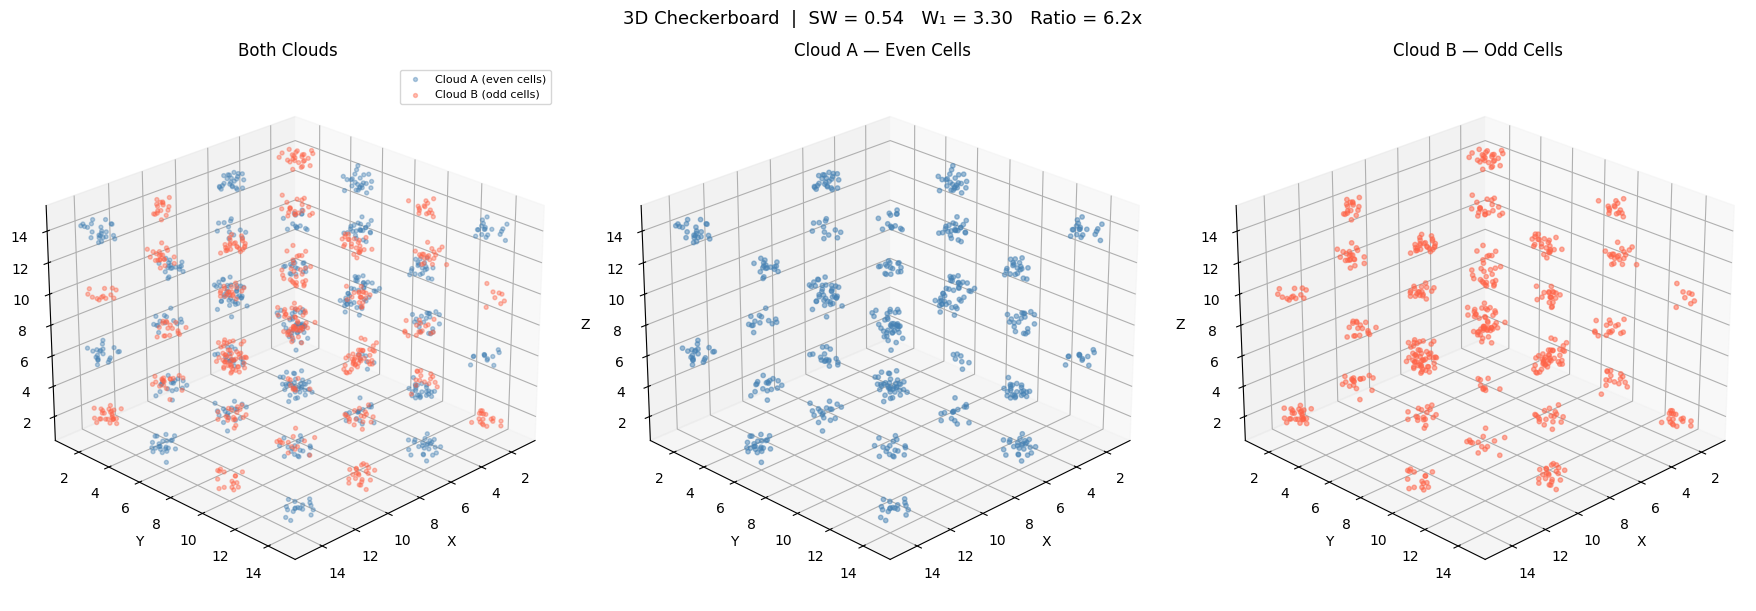

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 6))

# ── 1: Side-by-side clouds ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(*cloud_A.T, c='steelblue', alpha=0.4, s=8, label='Cloud A (even cells)')
ax1.scatter(*cloud_B.T, c='tomato',    alpha=0.4, s=8, label='Cloud B (odd cells)')
ax1.set_title('Both Clouds', fontsize=12)
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.legend(fontsize=8)

# ── 2: Cloud A alone ──────────────────────────────────────────────────────────
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(*cloud_A.T, c='steelblue', alpha=0.5, s=10)
ax2.set_title('Cloud A — Even Cells', fontsize=12)
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')

# ── 3: Cloud B alone ──────────────────────────────────────────────────────────
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(*cloud_B.T, c='tomato', alpha=0.5, s=10)
ax3.set_title('Cloud B — Odd Cells', fontsize=12)
ax3.set_xlabel('X'); ax3.set_ylabel('Y'); ax3.set_zlabel('Z')

# ── Sync all axes to same view and limits ─────────────────────────────────────
lim = [cloud_A.min() - 1, cloud_A.max() + 1]
for ax in [ax1, ax2, ax3]:
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_zlim(lim)
    ax.view_init(elev=25, azim=45)

plt.suptitle(
    f'3D Checkerboard  |  SW = {sw:.2f}   W₁ = {W:.2f}   Ratio = {W/sw:.1f}x',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('checkerboard_clouds.png', dpi=150, bbox_inches='tight')
plt.show()

# Replicating the Rings

Running Flexible (lp=1σ) (dt=0.005, n_eq=8000) ...
  step     0  Rg=12.22
  step  2000  Rg=8.04
  step  4000  Rg=6.67
  step  6000  Rg=6.10
  ✓  Rg = 5.29 σ

Running Semi-flexible (lp=5σ) (dt=0.003, n_eq=10000) ...
  step     0  Rg=12.22
  step  2500  Rg=4.88
  step  5000  Rg=4.33
  step  7500  Rg=3.86
  ✓  Rg = 3.88 σ

Running Stiff (lp=15σ) (dt=0.001, n_eq=15000) ...
  step     0  Rg=12.22
  step  3750  Rg=5.15
  step  7500  Rg=5.03
  step 11250  Rg=4.65
  ✓  Rg = 3.77 σ



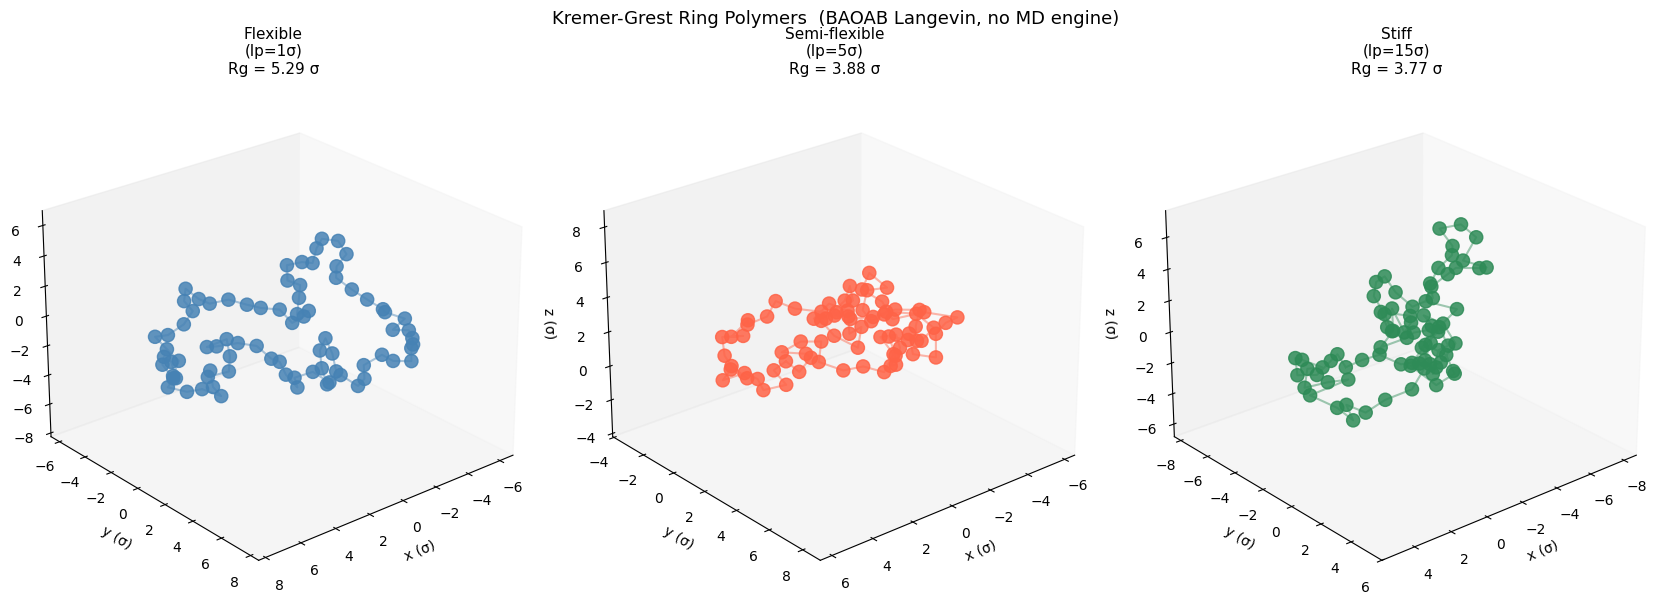

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

class KremerGrestRing:

    K_FENE  = 30.0
    R0_FENE = 1.5
    EPS_WCA = 1.0
    SIG_WCA = 1.0
    R_CUT2  = 2.0 ** (1/3)   # (2^(1/6))^2

    def __init__(self, N=60, lp=5.0, kBT=1.0, dt=0.005, seed=42, f_max=100.0):
        self.N     = N
        self.kBT   = kBT
        self.dt    = dt
        self.gamma = 1.0
        self.kappa = kBT * lp
        self.f_max = f_max          # force cap (σ·ε units)
        self.rng   = np.random.default_rng(seed)
        self._init_positions()

    def _init_positions(self):
        """Start on a clean planar circle — critical for stiff chains."""
        r_bond = 0.96
        R_init = self.N * r_bond / (2 * np.pi)
        theta  = np.linspace(0, 2*np.pi, self.N, endpoint=False)
        self.pos = np.column_stack([
            R_init * np.cos(theta),
            R_init * np.sin(theta),
            np.zeros(self.N)
        ])
        # very small noise so stiff chains aren't kicked hard at t=0
        noise_scale = 0.01 if self.kappa > 5 else 0.05
        self.pos += self.rng.normal(0, noise_scale, (self.N, 3))
        self.vel  = self.rng.normal(0, np.sqrt(self.kBT), (self.N, 3))

    # ── Forces ────────────────────────────────────────────────────────────────

    def _fene_forces(self):
        forces = np.zeros((self.N, 3))
        i  = np.arange(self.N)
        j  = (i + 1) % self.N
        dr = self.pos[j] - self.pos[i]
        r2 = np.sum(dr**2, axis=1).clip(1e-8, self.R0_FENE**2 - 1e-4)
        mag = -self.K_FENE / (1.0 - r2 / self.R0_FENE**2)
        f   = mag[:, None] * dr
        np.add.at(forces, i, -f)
        np.add.at(forces, j, +f)
        return forces

    def _wca_forces(self):
        dr   = self.pos[:, None] - self.pos[None]       # (N,N,3)
        r2   = np.sum(dr**2, axis=-1)                   # (N,N)
        np.fill_diagonal(r2, 1e10)
        mask = r2 < self.R_CUT2
        sr2  = np.where(mask, self.SIG_WCA**2 / r2.clip(1e-10), 0.0)
        sr6  = sr2**3
        sr12 = sr6**2
        fmag = np.where(mask,
                        24.0 * self.EPS_WCA * (2*sr12 - sr6) / r2.clip(1e-10),
                        0.0)
        return np.einsum('ij,ijk->ik', fmag, dr)

    def _bending_forces(self):
        forces = np.zeros((self.N, 3))
        i   = np.arange(self.N)
        im1 = (i - 1) % self.N
        ip1 = (i + 1) % self.N
        b1  = self.pos[i] - self.pos[im1]
        b2  = self.pos[ip1] - self.pos[i]
        l1  = np.linalg.norm(b1, axis=1, keepdims=True).clip(1e-10)
        l2  = np.linalg.norm(b2, axis=1, keepdims=True).clip(1e-10)
        u1  = b1 / l1
        u2  = b2 / l2
        cos_t = np.sum(u1 * u2, axis=1, keepdims=True).clip(-1+1e-7, 1-1e-7)
        f_ip1 = self.kappa * (u1 / l2 - cos_t * u2 / l2)
        f_im1 = self.kappa * (u2 / l1 - cos_t * u1 / l1)
        f_i   = -(f_ip1 + f_im1)
        np.add.at(forces, ip1, f_ip1)
        np.add.at(forces, im1, f_im1)
        np.add.at(forces, i,   f_i)
        return forces

    def _total_forces(self):
        f = self._fene_forces() + self._wca_forces() + self._bending_forces()
        # ── Force cap: prevents runaway from bad configurations ───────────────
        fnorm = np.linalg.norm(f, axis=1, keepdims=True)
        f     = np.where(fnorm > self.f_max, f * self.f_max / fnorm, f)
        return f

    # ── BAOAB Langevin integrator ─────────────────────────────────────────────

    def step(self):
        c1    = np.exp(-self.gamma * self.dt)
        c2    = np.sqrt((1 - c1**2) * self.kBT)
        f     = self._total_forces()
        self.vel += 0.5 * self.dt * f                                    # B
        self.pos += 0.5 * self.dt * self.vel                             # A
        self.vel  = c1 * self.vel + c2 * self.rng.normal(0,1,(self.N,3))# O
        self.pos += 0.5 * self.dt * self.vel                             # A
        f         = self._total_forces()
        self.vel += 0.5 * self.dt * f                                    # B

    def run(self, n_steps, verbose_every=0):
        for s in range(n_steps):
            self.step()
            if not np.isfinite(self.pos).all():
                raise RuntimeError(f"NaN/Inf at step {s} — reduce dt or increase f_max")
            if verbose_every and s % verbose_every == 0:
                Rg = np.sqrt(np.mean(np.sum((self.pos-self.pos.mean(0))**2, axis=1)))
                print(f"  step {s:>5d}  Rg={Rg:.2f}")
        return self.pos.copy()


# ══════════════════════════════════════════════════════════════════════════════
# Configs  — smaller dt for stiffer chains
# ══════════════════════════════════════════════════════════════════════════════

configs = [
    dict(label="Flexible\n(lp=1σ)",     lp=1,  N=80, dt=0.005, n_eq=8000,  seed=1),
    dict(label="Semi-flexible\n(lp=5σ)", lp=5,  N=80, dt=0.003, n_eq=10000, seed=2),
    dict(label="Stiff\n(lp=15σ)",        lp=15, N=80, dt=0.001, n_eq=15000, seed=3),
]

rings = []
for cfg in configs:
    label = cfg['label'].replace('\n', ' ')
    print(f"Running {label} (dt={cfg['dt']}, n_eq={cfg['n_eq']}) ...")
    sim = KremerGrestRing(N=cfg['N'], lp=cfg['lp'], dt=cfg['dt'], seed=cfg['seed'])
    pos = sim.run(cfg['n_eq'], verbose_every=cfg['n_eq']//4)
    Rg  = np.sqrt(np.mean(np.sum((pos - pos.mean(0))**2, axis=1)))
    print(f"  ✓  Rg = {Rg:.2f} σ\n")
    rings.append(pos)


# ══════════════════════════════════════════════════════════════════════════════
# Plot
# ══════════════════════════════════════════════════════════════════════════════

colors = ['steelblue', 'tomato', 'seagreen']
fig    = plt.figure(figsize=(17, 6))

for col, (pos, cfg, color) in enumerate(zip(rings, configs, colors)):
    ax  = fig.add_subplot(1, 3, col+1, projection='3d')
    cen = pos.mean(0)

    # ── Beads ─────────────────────────────────────────────────────────────────
    ax.scatter(*pos.T, c=color, s=90, alpha=0.85, depthshade=True, zorder=3)

    # ── Bonds (ring-closed) ───────────────────────────────────────────────────
    closed = np.vstack([pos, pos[0]])
    ax.plot(*closed.T, color=color, lw=1.5, alpha=0.45, zorder=2)

    # ── Safe axis limits ──────────────────────────────────────────────────────
    half = max(np.ptp(pos) / 2 + 1.5, 3.0)
    for setter, m in zip([ax.set_xlim, ax.set_ylim, ax.set_zlim], cen):
        setter([m - half, m + half])

    Rg = np.sqrt(np.mean(np.sum((pos - cen)**2, axis=1)))
    ax.set_title(f"{cfg['label']}\nRg = {Rg:.2f} σ", fontsize=11)
    ax.set_xlabel('x (σ)'); ax.set_ylabel('y (σ)'); ax.set_zlabel('z (σ)')
    ax.view_init(elev=25, azim=50)
    ax.grid(False)

plt.suptitle('Kremer-Grest Ring Polymers  (BAOAB Langevin, no MD engine)',
             fontsize=13, y=1.01)
plt.tight_layout()
#plt.savefig('kg_rings.png', dpi=150, bbox_inches='tight')
plt.show()

Flexible (lp=1)  vs  Semi-flexible (lp=5)
  W₁  = 4.5508
  SW₁ = 2.1703
  W/SW ratio = 2.10x

Flexible (lp=1)  vs  Stiff (lp=15)
  W₁  = 4.1469
  SW₁ = 1.8602
  W/SW ratio = 2.23x

Semi-flexible (lp=5)  vs  Stiff (lp=15)
  W₁  = 4.8786
  SW₁ = 2.3157
  W/SW ratio = 2.11x



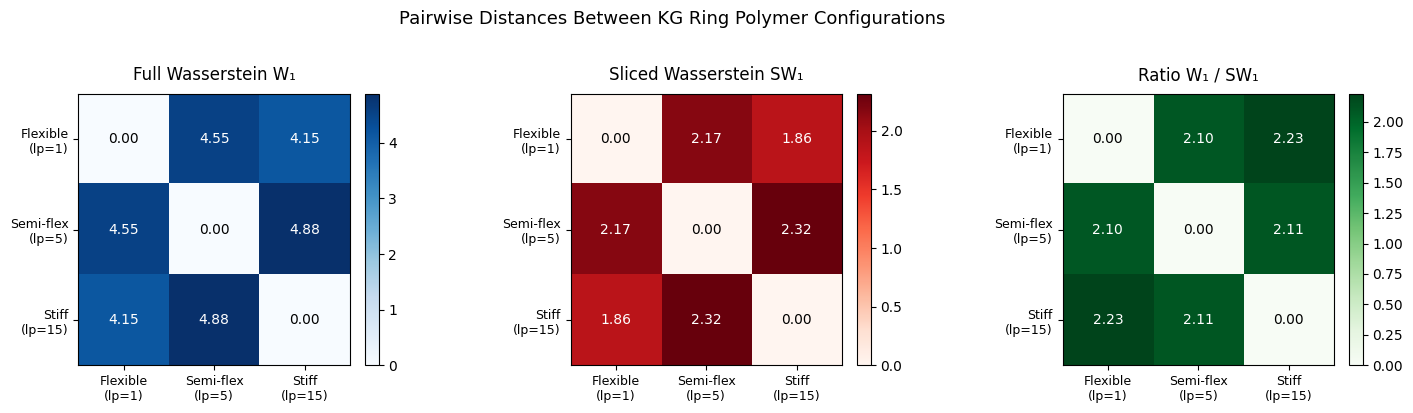

In [8]:
import ot
from ot import sliced_wasserstein_distance
from itertools import combinations

# ── Compute all pairwise distances ────────────────────────────────────────────
labels = ["Flexible (lp=1)", "Semi-flexible (lp=5)", "Stiff (lp=15)"]
pairs  = list(combinations(range(3), 2))

results = []
for i, j in pairs:
    A, B = rings[i], rings[j]
    N    = len(A)
    a    = np.ones(N) / N
    b    = np.ones(N) / N
    M    = ot.dist(A, B, metric='euclidean')

    W  = ot.emd2(a, b, M, numItermax=int(1e7))
    SW = sliced_wasserstein_distance(A, B, n_projections=1000, seed=0, p=1)

    results.append(dict(pair=(i, j), W=W, SW=SW, ratio=W/SW))
    print(f"{labels[i]}  vs  {labels[j]}")
    print(f"  W₁  = {W:.4f}")
    print(f"  SW₁ = {SW:.4f}")
    print(f"  W/SW ratio = {W/SW:.2f}x\n")


# ── Plot: distance matrix heatmaps ────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

n = 3
W_mat  = np.zeros((n, n))
SW_mat = np.zeros((n, n))

for r in results:
    i, j = r['pair']
    W_mat[i, j]  = W_mat[j, i]  = r['W']
    SW_mat[i, j] = SW_mat[j, i] = r['SW']

short = ["Flexible\n(lp=1)", "Semi-flex\n(lp=5)", "Stiff\n(lp=15)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, mat, title, cmap in zip(
    axes,
    [W_mat, SW_mat, W_mat / np.where(SW_mat > 0, SW_mat, 1)],
    ["Full Wasserstein W₁", "Sliced Wasserstein SW₁", "Ratio W₁ / SW₁"],
    ["Blues", "Reds", "Greens"]
):
    im = ax.imshow(mat, cmap=cmap, vmin=0)
    ax.set_xticks(range(n)); ax.set_xticklabels(short, fontsize=9)
    ax.set_yticks(range(n)); ax.set_yticklabels(short, fontsize=9)
    ax.set_title(title, fontsize=12, pad=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # annotate cells
    for row in range(n):
        for col in range(n):
            ax.text(col, row, f"{mat[row, col]:.2f}",
                    ha='center', va='center', fontsize=10,
                    color='white' if mat[row, col] > mat.max()*0.6 else 'black')

plt.suptitle("Pairwise Distances Between KG Ring Polymer Configurations",
             fontsize=13, y=1.02)
plt.tight_layout()
#plt.savefig('kg_distances.png', dpi=150, bbox_inches='tight')
plt.show()

Generating conformations ...
  Flexible (lp=1)  conf 1/8  Rg=5.55
  Flexible (lp=1)  conf 2/8  Rg=4.94
  Flexible (lp=1)  conf 3/8  Rg=4.44
  Flexible (lp=1)  conf 4/8  Rg=4.90
  Flexible (lp=1)  conf 5/8  Rg=4.81
  Flexible (lp=1)  conf 6/8  Rg=5.99
  Flexible (lp=1)  conf 7/8  Rg=5.78
  Flexible (lp=1)  conf 8/8  Rg=4.96
  Semi-flex (lp=5)  conf 1/8  Rg=3.63
  Semi-flex (lp=5)  conf 2/8  Rg=3.29
  Semi-flex (lp=5)  conf 3/8  Rg=4.21
  Semi-flex (lp=5)  conf 4/8  Rg=4.52
  Semi-flex (lp=5)  conf 5/8  Rg=3.70
  Semi-flex (lp=5)  conf 6/8  Rg=3.53
  Semi-flex (lp=5)  conf 7/8  Rg=4.00
  Semi-flex (lp=5)  conf 8/8  Rg=3.99
  Stiff (lp=15)  conf 1/8  Rg=4.36
  Stiff (lp=15)  conf 2/8  Rg=3.58
  Stiff (lp=15)  conf 3/8  Rg=4.54
  Stiff (lp=15)  conf 4/8  Rg=3.93
  Stiff (lp=15)  conf 5/8  Rg=5.17
  Stiff (lp=15)  conf 6/8  Rg=5.14
  Stiff (lp=15)  conf 7/8  Rg=3.94
  Stiff (lp=15)  conf 8/8  Rg=4.43

Computing pairwise distances ...
  ( 0, 1)  W=1.848  SW=0.649
  ( 0, 2)  W=4.154  SW=2.001

/Users/MAlghalayini/Desktop/Postdoc Work/CAMERA gpLVM/Github Repository/Flexible_kernels/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/Users/MAlghalayini/Desktop/Postdoc Work/CAMERA gpLVM/Github Repository/Flexible_kernels/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


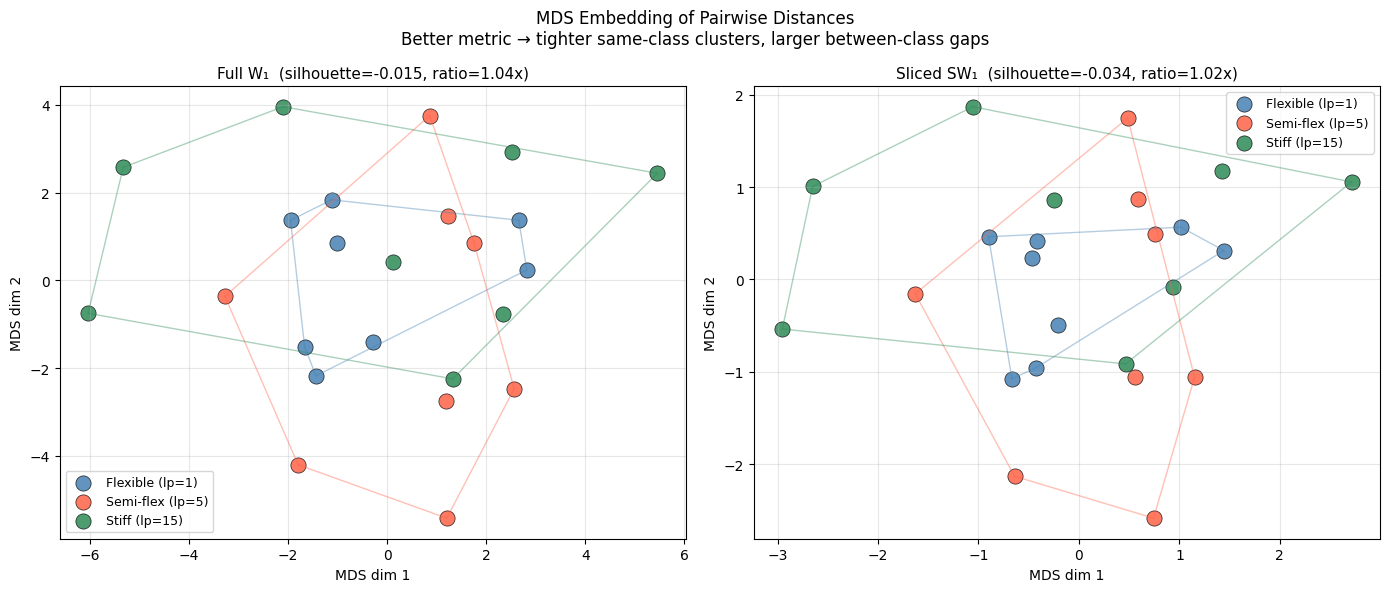

In [9]:
import numpy as np
import ot
from ot import sliced_wasserstein_distance
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from itertools import combinations

# ══════════════════════════════════════════════════════════════════════════════
# Step 1: Generate multiple independent conformations per stiffness level
# Ground truth: same lp = same class → should be close
#               diff lp = diff class → should be far
# ══════════════════════════════════════════════════════════════════════════════

lp_configs = [
    dict(lp=1,  label="Flexible (lp=1)",     dt=0.005, n_eq=8000,  color='steelblue'),
    dict(lp=5,  label="Semi-flex (lp=5)",    dt=0.003, n_eq=10000, color='tomato'),
    dict(lp=15, label="Stiff (lp=15)",       dt=0.001, n_eq=15000, color='seagreen'),
]

N_CONF   = 8     # independent conformations per class
N_BEADS  = 80
all_conf = []    # list of (pos, class_label)

print("Generating conformations ...")
for cls_idx, cfg in enumerate(lp_configs):
    for k in range(N_CONF):
        seed = cls_idx * 100 + k
        sim  = KremerGrestRing(N=N_BEADS, lp=cfg['lp'], dt=cfg['dt'], seed=seed)
        sim.run(cfg['n_eq'])
        # collect a snapshot every 500 steps to decorrelate slightly
        sim.run(500)
        pos = sim.run(1)
        all_conf.append((pos, cls_idx))
        print(f"  {cfg['label']}  conf {k+1}/{N_CONF}  "
              f"Rg={np.sqrt(np.mean(np.sum((pos-pos.mean(0))**2,axis=1))):.2f}")

n_total = len(all_conf)   # = 3 * N_CONF = 24
labels  = np.array([c[1] for c in all_conf])
confs   = [c[0] for c in all_conf]

# ══════════════════════════════════════════════════════════════════════════════
# Step 2: Compute full pairwise distance matrices for both metrics
# ══════════════════════════════════════════════════════════════════════════════

D_W  = np.zeros((n_total, n_total))
D_SW = np.zeros((n_total, n_total))

print("\nComputing pairwise distances ...")
for i, j in combinations(range(n_total), 2):
    A, B = confs[i], confs[j]
    N    = len(A)
    a    = np.ones(N) / N
    b    = np.ones(N) / N
    M    = ot.dist(A, B, metric='euclidean')

    w  = ot.emd2(a, b, M, numItermax=int(1e7))
    sw = sliced_wasserstein_distance(A, B, n_projections=500, seed=0, p=1)

    D_W[i, j]  = D_W[j, i]  = w
    D_SW[i, j] = D_SW[j, i] = sw
    print(f"  ({i:2d},{j:2d})  W={w:.3f}  SW={sw:.3f}")

# ══════════════════════════════════════════════════════════════════════════════
# Step 3: Evaluate class separation — the better metric has:
#   - LOW  intra-class distance  (same lp → same shape)
#   - HIGH inter-class distance  (diff lp → diff shape)
# ══════════════════════════════════════════════════════════════════════════════

def class_separation(D, labels):
    """Returns intra, inter distances and silhouette score."""
    intra, inter = [], []
    for i, j in combinations(range(len(labels)), 2):
        (intra if labels[i] == labels[j] else inter).append(D[i, j])
    sil = silhouette_score(D, labels, metric='precomputed')
    return np.mean(intra), np.mean(inter), sil

intra_W,  inter_W,  sil_W  = class_separation(D_W,  labels)
intra_SW, inter_SW, sil_SW = class_separation(D_SW, labels)

sep_W  = inter_W  / intra_W
sep_SW = inter_SW / intra_SW

print("\n" + "="*55)
print(f"{'Metric':<10} {'Intra':>8} {'Inter':>8} {'Ratio':>8} {'Silhouette':>12}")
print("-"*55)
print(f"{'W₁':<10} {intra_W:>8.3f} {inter_W:>8.3f} {sep_W:>8.2f} {sil_W:>12.4f}")
print(f"{'SW₁':<10} {intra_SW:>8.3f} {inter_SW:>8.3f} {sep_SW:>8.2f} {sil_SW:>12.4f}")
print("="*55)
print(f"\nW₁  separation advantage: {sep_W/sep_SW:.2f}x over SW₁")

# ══════════════════════════════════════════════════════════════════════════════
# Step 4: Visualise — MDS embedding of both distance matrices
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.manifold import MDS

colors_all = [lp_configs[l]['color'] for l in labels]
class_labels = [lp_configs[l]['label'] for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, D, title in zip(axes,
                         [D_W, D_SW],
                         [f"Full W₁  (silhouette={sil_W:.3f}, ratio={sep_W:.2f}x)",
                          f"Sliced SW₁  (silhouette={sil_SW:.3f}, ratio={sep_SW:.2f}x)"]):

    mds  = MDS(n_components=2, dissimilarity='precomputed', random_state=0, normalized_stress=False)
    emb  = mds.fit_transform(D)

    for cls_idx, cfg in enumerate(lp_configs):
        mask = labels == cls_idx
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=cfg['color'], s=120, alpha=0.85,
                   label=cfg['label'], edgecolors='k', linewidths=0.5)

        # draw convex hull per class to show cluster tightness
        from scipy.spatial import ConvexHull
        pts = emb[mask]
        if len(pts) >= 3:
            hull = ConvexHull(pts)
            for simplex in hull.simplices:
                ax.plot(pts[simplex, 0], pts[simplex, 1],
                        color=cfg['color'], lw=1, alpha=0.4)

    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlabel('MDS dim 1')
    ax.set_ylabel('MDS dim 2')
    ax.grid(True, alpha=0.3)

plt.suptitle('MDS Embedding of Pairwise Distances\n'
             'Better metric → tighter same-class clusters, larger between-class gaps',
             fontsize=12)
plt.tight_layout()
# plt.savefig('metric_comparison_mds.png', dpi=150, bbox_inches='tight')
plt.show()

Building ensemble densities ...
  Flexible (lp=1): 3200 total beads, mean Rg = 5.05 σ
  Semi-flex (lp=5): 3200 total beads, mean Rg = 3.87 σ
  Stiff (lp=15): 3200 total beads, mean Rg = 4.99 σ

── Pairwise distances between ensemble densities ──
Pair                                      W₁      SW₁    Ratio
--------------------------------------------------------------
Flexible (lp=1)  vs  Semi-flex (lp=5)   1.4571   0.5717     2.55x
Flexible (lp=1)  vs  Stiff (lp=15)    1.0796   0.2595     4.16x
Semi-flex (lp=5)  vs  Stiff (lp=15)   1.5276   0.5763     2.65x


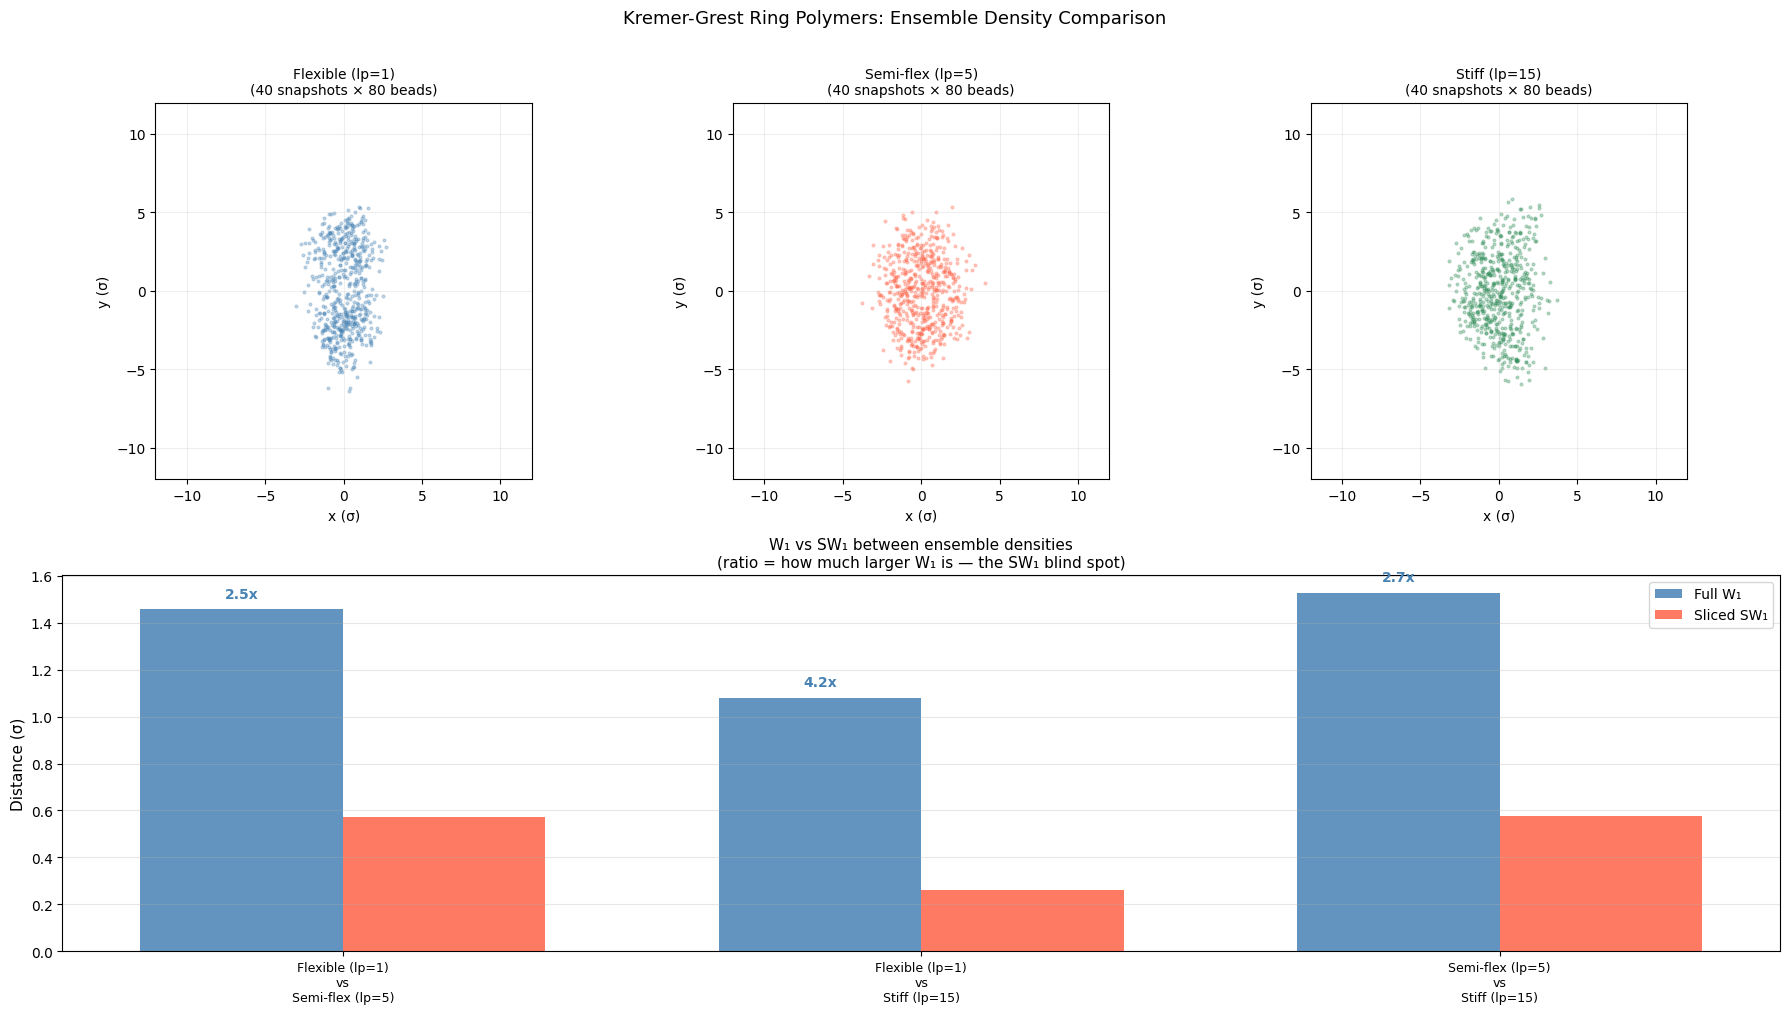

In [10]:
import numpy as np
import ot
from ot import sliced_wasserstein_distance
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# Build one 3D density cloud per stiffness class
# by accumulating bead positions across many conformations,
# centring each conformation before accumulating (remove translational drift)
# ══════════════════════════════════════════════════════════════════════════════

lp_configs = [
    dict(lp=1,  label="Flexible (lp=1)",    dt=0.005, n_eq=8000,  color='steelblue'),
    dict(lp=5,  label="Semi-flex (lp=5)",   dt=0.003, n_eq=10000, color='tomato'),
    dict(lp=15, label="Stiff (lp=15)",      dt=0.001, n_eq=15000, color='seagreen'),
]

N_SNAPSHOTS = 40    # snapshots per class — each separated by 200 steps
N_BEADS     = 80
SNAP_GAP    = 200   # steps between snapshots (decorrelation)

densities = []   # one (N_BEADS * N_SNAPSHOTS, 3) array per class

print("Building ensemble densities ...")
for cfg in lp_configs:
    sim  = KremerGrestRing(N=N_BEADS, lp=cfg['lp'], dt=cfg['dt'], seed=42)
    sim.run(cfg['n_eq'])   # equilibrate

    cloud = []
    for snap in range(N_SNAPSHOTS):
        sim.run(SNAP_GAP)
        pos = sim.pos.copy()
        pos -= pos.mean(0)   # centre — remove translation
        # ── align principal axis to z (removes rotation variance) ────────────
        cov  = pos.T @ pos / N_BEADS
        eigvals, eigvecs = np.linalg.eigh(cov)
        pos  = pos @ eigvecs   # rotate into principal frame
        cloud.append(pos)

    density = np.vstack(cloud)   # (N_BEADS * N_SNAPSHOTS, 3)
    densities.append(density)

    Rg_mean = np.mean([
        np.sqrt(np.mean(np.sum(c**2, axis=1)))
        for c in cloud
    ])
    print(f"  {cfg['label']}: {len(density)} total beads, mean Rg = {Rg_mean:.2f} σ")


# ══════════════════════════════════════════════════════════════════════════════
# Subsample to equal size for fair comparison
# ══════════════════════════════════════════════════════════════════════════════

N_sub = 600
rng   = np.random.default_rng(0)
clouds = [
    d[rng.choice(len(d), N_sub, replace=False)]
    for d in densities
]

# ══════════════════════════════════════════════════════════════════════════════
# Pairwise W₁ and SW₁ between the three ensemble densities
# ══════════════════════════════════════════════════════════════════════════════

from itertools import combinations

a = np.ones(N_sub) / N_sub
b = np.ones(N_sub) / N_sub

print("\n── Pairwise distances between ensemble densities ──")
print(f"{'Pair':<35} {'W₁':>8} {'SW₁':>8} {'Ratio':>8}")
print("-" * 62)

results = {}
for i, j in combinations(range(3), 2):
    A, B = clouds[i], clouds[j]
    M    = ot.dist(A, B, metric='euclidean')
    W    = ot.emd2(a, b, M, numItermax=int(1e7))
    SW   = sliced_wasserstein_distance(A, B, n_projections=1000, seed=0, p=1)
    key  = (i, j)
    results[key] = dict(W=W, SW=SW)
    lbl  = f"{lp_configs[i]['label']}  vs  {lp_configs[j]['label']}"
    print(f"{lbl:<35} {W:>8.4f} {SW:>8.4f} {W/SW:>8.2f}x")


# ══════════════════════════════════════════════════════════════════════════════
# Plot: 2D projections of ensemble densities + distance bar chart
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 10))

# ── Row 1: XY projections of each ensemble density ───────────────────────────
for col, (cloud, cfg) in enumerate(zip(clouds, lp_configs)):
    ax = fig.add_subplot(2, 3, col + 1)
    ax.scatter(cloud[:, 0], cloud[:, 1],
               c=cfg['color'], s=4, alpha=0.3)
    ax.set_title(f"{cfg['label']}\n({N_SNAPSHOTS} snapshots × {N_BEADS} beads)",
                 fontsize=10)
    ax.set_xlabel('x (σ)'); ax.set_ylabel('y (σ)')
    ax.set_aspect('equal')
    ax.set_xlim(-12, 12); ax.set_ylim(-12, 12)
    ax.grid(True, alpha=0.2)

# ── Row 2: Bar chart comparing W₁ vs SW₁ for each pair ───────────────────────
ax_bar = fig.add_subplot(2, 1, 2)
pair_labels = [
    f"{lp_configs[i]['label']}\nvs\n{lp_configs[j]['label']}"
    for i, j in combinations(range(3), 2)
]
W_vals  = [results[(i,j)]['W']  for i, j in combinations(range(3), 2)]
SW_vals = [results[(i,j)]['SW'] for i, j in combinations(range(3), 2)]

x      = np.arange(len(pair_labels))
width  = 0.35
bars_W  = ax_bar.bar(x - width/2, W_vals,  width, label='Full W₁',    color='steelblue', alpha=0.85)
bars_SW = ax_bar.bar(x + width/2, SW_vals, width, label='Sliced SW₁', color='tomato',    alpha=0.85)

# annotate ratio on top of each W₁ bar
for xi, (w, sw) in zip(x, zip(W_vals, SW_vals)):
    ax_bar.text(xi - width/2, w + 0.05, f"{w/sw:.1f}x",
                ha='center', fontsize=10, color='steelblue', fontweight='bold')

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(pair_labels, fontsize=9)
ax_bar.set_ylabel('Distance (σ)', fontsize=11)
ax_bar.set_title('W₁ vs SW₁ between ensemble densities\n'
                 '(ratio = how much larger W₁ is — the SW₁ blind spot)',
                 fontsize=11)
ax_bar.legend(fontsize=10)
ax_bar.grid(axis='y', alpha=0.3)

plt.suptitle('Kremer-Grest Ring Polymers: Ensemble Density Comparison',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('ensemble_density_comparison.png', dpi=150, bbox_inches='tight')
plt.show()